# 누적 복습 2. Linnerud 운동 데이터 회귀

## 난이도
- 간단한 복습 문제

## 데이터셋 설명
- `sklearn.datasets.load_linnerud()` 데이터셋을 사용함.
- 20명의 운동 수행 기록과 신체 측정값을 담은 작은 회귀 예제 데이터임.
- 입력 feature는 운동 수행량임.
  - `Chins`: 턱걸이 횟수
  - `Situps`: 윗몸일으키기 횟수
  - `Jumps`: 점프 횟수
- target은 신체 측정값 중 `Weight`를 사용함.

## 복습 범위
- 다중 선형 회귀
- Ridge 회귀
- Random Forest 회귀
- R2, RMSE 해석
- 실제값과 예측값 비교 시각화


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_linnerud
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, root_mean_squared_error

linnerud = load_linnerud(as_frame=True)

exercise_df = linnerud.data.copy()
body_df = linnerud.target.copy()
linnerud_df = pd.concat([exercise_df, body_df], axis=1)

X = exercise_df
y = body_df['Weight']

print('데이터 크기:', linnerud_df.shape)
print('feature:', list(X.columns))
print('target: Weight')
display(linnerud_df.head())


데이터 크기: (20, 6)
feature: ['Chins', 'Situps', 'Jumps']
target: Weight


,Chins,Situps,Jumps,Weight,Waist,Pulse
0,5.0,162.0,60.0,191.0,36.0,50.0
1,2.0,110.0,60.0,189.0,37.0,52.0
2,12.0,101.0,101.0,193.0,38.0,58.0
3,12.0,105.0,37.0,162.0,35.0,62.0
4,13.0,155.0,58.0,189.0,35.0,46.0


## 문제 1. 회귀용 데이터 분리와 스케일링

운동 수행량으로 체중을 예측할 수 있도록 학습/평가 데이터를 나누고 스케일링하세요.

### 요구사항
- `train_test_split()` 사용
- `test_size=0.25`, `random_state=42` 사용
- `StandardScaler()` 사용
- 학습 데이터에는 `fit_transform()`, 평가 데이터에는 `transform()` 사용
- 분리 결과 shape 출력

### 힌트
- 데이터 수가 20개로 매우 작으므로 점수 변동이 클 수 있음.
- 작은 데이터에서는 평가 결과를 절대적인 성능으로 해석하기보다 실습 흐름 이해에 초점을 둠.


In [2]:
# 작성: train_test_split()으로 학습/평가 데이터를 분리하세요.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 작성: StandardScaler()로 학습/평가 데이터를 스케일링하세요.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 작성: 분리 결과 shape를 출력하세요.
print(X_train_scaled.shape, y_train.shape)
print(X_test_scaled.shape, y_test.shape)

(15, 3) (15,)
(5, 3) (5,)


## 문제 2. 회귀 모델 3개 성능 비교

Linear Regression, Ridge, Random Forest Regressor를 학습하고 R2와 RMSE를 비교하세요.

### 요구사항
- `LinearRegression()` 사용
- `Ridge(alpha=1.0)` 사용
- `RandomForestRegressor(n_estimators=200, random_state=42)` 사용
- 결과 컬럼: `model`, `train_R2`, `test_R2`, `test_RMSE`
- 결과를 DataFrame으로 출력

### 힌트
- R2는 높을수록 좋고, RMSE는 낮을수록 좋음.
- 작은 데이터에서는 Random Forest가 훈련 데이터를 잘 맞추더라도 평가 성능이 안정적이지 않을 수 있음.


In [3]:
# 작성: Linear Regression, Ridge, Random Forest Regressor 모델을 준비하세요.
regression_models = {
    'linear_regression' : LinearRegression(),
    'ridge' : Ridge(alpha = 1.0),
    'random_forest' : RandomForestRegressor(n_estimators = 200, random_state = 42),
}

# 작성: 반복문으로 모델을 학습하고 R2/RMSE를 results에 저장하세요.
regression_results = []

for name, model in regression_models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    regression_results.append({
        'model': name,
        'test_R2': r2_score(y_test, y_pred),
        'test_RMSE': root_mean_squared_error(y_test, y_pred),
    })

# 작성: 결과를 DataFrame으로 출력하세요.
regression_result_df = pd.DataFrame(regression_results)
display(regression_result_df)

,model,test_R2,test_RMSE
0,linear_regression,-2.227171,27.667399
1,ridge,-1.489925,24.302475
2,random_forest,-1.519587,24.446801


## 문제 3. 새 운동 기록의 체중 예측과 그래프 확인

평가 RMSE가 가장 낮은 모델을 선택해 새 운동 기록의 체중을 예측하고, 실제값과 예측값을 산점도로 비교하세요.

### 요구사항
- 가장 낮은 `test_RMSE` 모델 선택
- 새 데이터 2개 예측
- 평가 데이터의 실제값과 예측값 산점도 그리기

### 힌트
- 새 데이터도 학습 데이터 기준으로 만든 scaler로 `transform()` 해야 함.
- 실제값과 예측값이 비슷하면 산점도가 대각선 근처에 놓임.


새 데이터 2개 예측:  [187.00235098 179.24634185]


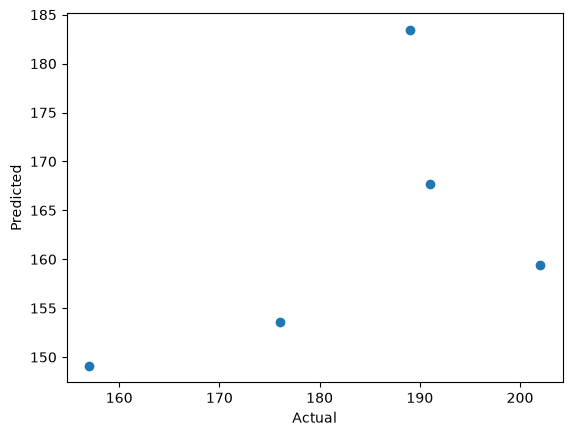

In [8]:
# 작성: result_df에서 test_RMSE가 가장 낮은 모델을 선택하세요.
regression_result_df = pd.DataFrame(regression_results).sort_values('test_RMSE')
best_model_name = regression_result_df.iloc[0]['model']
best_model = regression_models[best_model_name]

# 작성: 새 운동 기록 2개를 DataFrame으로 만들고 스케일링 후 예측하세요.
new_exercise = pd.DataFrame({
    'Chins': [8, 15],
    'Situps': [90, 120],
    'Jumps': [40, 55]
})

new_exercise_scaled = scaler.transform(new_exercise)
new_pred = best_model.predict(new_exercise_scaled)

print("새 데이터 2개 예측: ", new_pred)

# 작성: 평가 데이터 실제값과 예측값을 산점도로 시각화하세요.
y_pred = best_model.predict(X_test_scaled)
plt.scatter(y_test, y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()